In [56]:
from corpus import corpus
words_to_visualize = ["machine", "learning", "neural", "intelligence", "python", "data", "Artificial", "transforming","industries"]

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(corpus)

# TF-IDF embedding for each word
tfidf_embeddings = []
for word in words_to_visualize:
    if word in vectorizer.vocabulary_:
        idx = vectorizer.vocabulary_[word]
        word_vector = X_tfidf[:, idx].toarray().flatten()  # column across all docs
        tfidf_embeddings.append(word_vector)
    else:
        # If word not in corpus, use zeros
        tfidf_embeddings.append(np.zeros(X_tfidf.shape[0]))

tfidf_embeddings = np.array(tfidf_embeddings)
print("TF-IDF embeddings shape:", tfidf_embeddings.shape)

TF-IDF embeddings shape: (9, 8)


In [58]:
print("TF-IDF embedding for 'machine':",tfidf_embeddings[0])

TF-IDF embedding for 'machine': [0.4027632  0.         0.         0.         0.         0.34422251
 0.         0.        ]


In [59]:
import gensim.downloader as api

# Load pre-trained GloVe vectors
glove_model = api.load("glove-wiki-gigaword-100")  # 100-dim vectors

glove_embeddings = []
for word in words_to_visualize:
    try:
        glove_embeddings.append(glove_model[word.lower()])
    except KeyError:
        glove_embeddings.append(np.zeros(glove_model.vector_size))

glove_embeddings = np.array(glove_embeddings)
print("GloVe embeddings shape:", glove_embeddings.shape)


GloVe embeddings shape: (9, 100)


In [60]:
print(glove_embeddings)

[[-6.5365e-01  4.9419e-01 -2.6245e-01 -2.0722e-01 -1.1413e-01  3.5701e-01
   1.0454e+00  2.1881e-01  5.2769e-01  6.0606e-01  4.2521e-01 -6.5169e-01
   1.5318e-01 -1.4797e-01  1.2651e-01 -1.7124e-02  4.5325e-01  3.7166e-01
  -2.6847e-01 -2.6270e-01  4.3869e-01 -1.6615e-02  1.2714e-01 -5.4708e-01
   8.9084e-02  2.4336e-01 -3.4415e-01  2.6505e-03 -9.4268e-02  5.6114e-02
   4.6366e-01  6.8786e-01 -2.0631e-01 -8.8003e-02  3.2153e-01 -9.1399e-01
  -8.0976e-02 -9.0761e-01  9.2889e-01 -6.8033e-01  2.3801e-01 -3.7469e-01
  -4.3278e-01 -1.9243e-01 -2.3711e-01 -7.3041e-01 -5.0592e-01 -3.0237e-01
   1.7281e-03 -6.0923e-01 -2.1046e-01  4.7403e-01  3.7333e-01  1.2475e+00
   6.2990e-01 -1.5292e+00 -3.2403e-01  5.9681e-01  9.7994e-01  5.9756e-01
   6.7625e-01  2.8223e-01 -2.6748e-01  1.4250e+00 -3.4419e-01  2.5212e-01
   3.0240e-01 -2.6582e-01 -2.2583e-01  5.3783e-01 -4.4439e-01 -2.4281e-01
   3.8001e-01  8.5317e-02  4.9694e-01  2.4058e-01  2.0611e-01  2.3896e-02
  -5.3078e-01  1.2086e-01  1.1627e+00 

In [61]:
from sklearn.manifold import TSNE

# t-SNE for TF-IDF
tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=2)
tfidf_2d = tsne_tfidf.fit_transform(tfidf_embeddings)

# t-SNE for GloVe
tsne_glove = TSNE(n_components=2, random_state=42, perplexity=2)
glove_2d = tsne_glove.fit_transform(glove_embeddings)

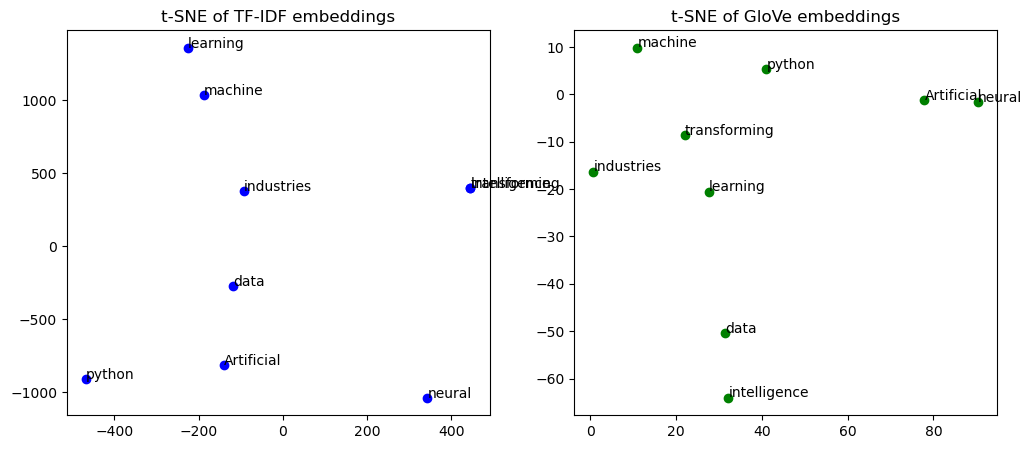

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# TF-IDF plot
plt.subplot(1,2,1)
plt.scatter(tfidf_2d[:,0], tfidf_2d[:,1], color='blue')
for i, word in enumerate(words_to_visualize):
    plt.annotate(word, (tfidf_2d[i,0]+0.1, tfidf_2d[i,1]+0.1))
plt.title("t-SNE of TF-IDF embeddings")

# GloVe plot
plt.subplot(1,2,2)
plt.scatter(glove_2d[:,0], glove_2d[:,1], color='green')
for i, word in enumerate(words_to_visualize):
    plt.annotate(word, (glove_2d[i,0]+0.1, glove_2d[i,1]+0.1))
plt.title("t-SNE of GloVe embeddings")

plt.show()